In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [2]:
class GreetState(BaseModel):
    message: str = ""

In [3]:
graph = StateGraph(GreetState)

In [4]:
# Nodes - Python Functions

def Greet(state: GreetState):
    state.message = f"{state.message} ! All good!"
    return state

def upperCase(state: GreetState):
    state.message = state.message.upper()
    return state

In [5]:
graph.add_node("greet", Greet)

graph.add_node("upper", upperCase)

In [6]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper")
graph.add_edge("upper", END)

In [7]:
final_graph = graph.compile()

In [8]:
res = final_graph.invoke({"message":"Hello"})

In [9]:
res

{'message': 'HELLO ! ALL GOOD!'}

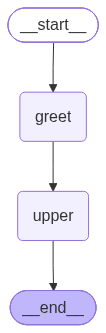

In [10]:
from IPython.display import Image

Image(final_graph.get_graph().draw_mermaid_png())